In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Load the cleaned data we saved in Phase 2
logs_df = pd.read_csv("data/processed/logs_parsed.csv")

print(f" Data loaded!")
print(f"   Shape  : {logs_df.shape}")
print(f"   Columns: {list(logs_df.columns)}")
print()
print(logs_df.head(3))

 Data loaded!
   Shape  : (11175629, 10)
   Columns: ['Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'BlockId', 'Label_x', 'Label_y', 'Label']

    Date    Time  Pid Level                 Component  \
0  81109  203518  143  INFO  dfs.DataNode$DataXceiver   
1  81109  203518   35  INFO          dfs.FSNamesystem   
2  81109  203519  143  INFO  dfs.DataNode$DataXceiver   

                                             Content  \
0  Receiving block blk_-1608999687919862906 src: ...   
1  BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...   
2  Receiving block blk_-1608999687919862906 src: ...   

                    BlockId Label_x Label_y   Label  
0  blk_-1608999687919862906  Normal  Normal  Normal  
1  blk_-1608999687919862906  Normal  Normal  Normal  
2  blk_-1608999687919862906  Normal  Normal  Normal  


In [4]:
# Keep only Normal and Anomaly rows
# (drop 'Unknown' rows where BlockId was None)

logs_labeled = logs_df[logs_df['Label'].isin(['Normal', 'Anomaly'])].copy()

print(f" Labeled rows kept : {len(logs_labeled):,}")
print(f"   Dropped (Unknown): {len(logs_df) - len(logs_labeled):,}")
print()
print("Label counts:")
print(logs_labeled['Label'].value_counts())

 Labeled rows kept : 11,175,629
   Dropped (Unknown): 0

Label counts:
Label
Normal     10887379
Anomaly      288250
Name: count, dtype: int64


In [5]:
# Feature 1: How many log lines does each Block ID generate?
# Anomalous blocks often generate unusually many or few log lines

session_length = (
    logs_labeled
    .groupby('BlockId')
    .size()
    .reset_index(name='session_length')
)

print(f" Feature 1 created: session_length")
print(f"   Unique sessions : {len(session_length):,}")
print()
print("Session length statistics:")
print(session_length['session_length'].describe())

 Feature 1 created: session_length
   Unique sessions : 575,061

Session length statistics:
count    575061.000000
mean         19.433815
std           5.177735
min           2.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: session_length, dtype: float64


In [6]:
# Feature 2: Count of each log level per session
# Anomalous sessions tend to have more WARN and ERROR entries

level_counts = (
    logs_labeled
    .groupby(['BlockId', 'Level'])
    .size()
    .unstack(fill_value=0)   # Each level becomes its own column
    .reset_index()
)

# Rename columns clearly
level_counts.columns.name = None

# Make sure all expected columns exist even if missing
for level in ['INFO', 'WARN', 'ERROR', 'DEBUG']:
    if level not in level_counts.columns:
        level_counts[level] = 0

# Rename to make purpose clear
level_counts = level_counts.rename(columns={
    'INFO'  : 'count_INFO',
    'WARN'  : 'count_WARN',
    'ERROR' : 'count_ERROR',
    'DEBUG' : 'count_DEBUG'
})

print(f" Feature 2 created: log level counts")
print(level_counts.head())

 Feature 2 created: log level counts
                    BlockId  count_INFO  count_WARN  count_ERROR  count_DEBUG
0  blk_-1000002529962039464          13           0            0            0
1   blk_-100000266894974466          25           3            0            0
2  blk_-1000007292892887521          13           0            0            0
3  blk_-1000014584150379967          26           3            0            0
4  blk_-1000028658773048709          19           0            0            0


In [7]:
# Feature 3: How many distinct system components are involved per session?
# Anomalies often span fewer OR more components than normal operations

unique_components = (
    logs_labeled
    .groupby('BlockId')['Component']
    .nunique()
    .reset_index(name='unique_components')
)

print(f" Feature 3 created: unique_components")
print(unique_components['unique_components'].describe())

 Feature 3 created: unique_components
count    575061.000000
mean          3.963896
std           0.623632
min           2.000000
25%           4.000000
50%           4.000000
75%           4.000000
max           8.000000
Name: unique_components, dtype: float64


In [9]:
# Feature 4: Count of log lines per top component per session
# This captures WHICH components were active — a strong anomaly signal

# Get top 5 most frequent components
top5_components = (
    logs_labeled['Component']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top 5 components:", top5_components)

# Count lines from each top component per session
comp_counts = (
    logs_labeled[logs_labeled['Component'].isin(top5_components)]
    .groupby(['BlockId', 'Component'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

comp_counts.columns.name = None

# Rename columns
comp_counts.columns = (
    ['BlockId'] + [f'comp_{c.split("$")[-1]}' 
                   for c in comp_counts.columns[1:]]
)

print(f"\n Feature 4 created: component frequencies")
print(comp_counts.head())

Top 5 components: ['dfs.FSNamesystem', 'dfs.DataNode$PacketResponder', 'dfs.DataNode$DataXceiver', 'dfs.FSDataset', 'dfs.DataBlockScanner']

 Feature 4 created: component frequencies
                    BlockId  comp_dfs.DataBlockScanner  comp_DataXceiver  \
0  blk_-1000002529962039464                          0                 3   
1   blk_-100000266894974466                          0                12   
2  blk_-1000007292892887521                          0                 3   
3  blk_-1000014584150379967                          1                12   
4  blk_-1000028658773048709                          0                 3   

   comp_PacketResponder  comp_dfs.FSDataset  comp_dfs.FSNamesystem  
0                     6                   0                      4  
1                     6                   3                      7  
2                     6                   0                      4  
3                     6                   3                      7  
4              

In [9]:
# Feature 5: Time span and activity rate of each session
# Anomalous sessions may complete unusually fast or slow

# Convert Time column to proper integer
logs_labeled['Time'] = logs_labeled['Time'].astype(str).str.strip()
logs_labeled['Time_int'] = pd.to_numeric(logs_labeled['Time'], errors='coerce')

time_features = (
    logs_labeled
    .groupby('BlockId')['Time_int']
    .agg(
        first_seen='min',    # When session started
        last_seen='max',     # When session ended
    )
    .reset_index()
)

# Duration = difference between first and last log entry
time_features['duration'] = (
    time_features['last_seen'] - time_features['first_seen']
)

# Drop helper columns, keep only duration
time_features = time_features[['BlockId', 'duration']]

print(f" Feature 5 created: duration")
print(time_features['duration'].describe())

 Feature 5 created: duration
count    575061.000000
mean      58915.512619
std       67523.628691
min           0.000000
25%        4509.000000
50%       20045.000000
75%      102807.000000
max      235959.000000
Name: duration, dtype: float64


In [16]:
# Feature 6: Keyword flags — OPTIMIZED VERSION
# Instead of 6 separate passes, we do ONE pass through the content

print(" Extracting keyword features (optimized)...")

# Keywords we care about
keywords = ['exception', 'failed', 'error', 'timeout', 'replicat', 'served']

# Convert content to lowercase ONCE (not 6 times)
logs_labeled['Content_lower'] = logs_labeled['Content'].str.lower()

# Create one binary column per keyword in the main dataframe
for kw in keywords:
    logs_labeled[f'kw_{kw}'] = logs_labeled['Content_lower'].str.contains(kw).astype(int)

# Now group by BlockId and sum — much faster than lambda agg
kw_cols = [f'kw_{kw}' for kw in keywords]
keyword_features = (
    logs_labeled
    .groupby('BlockId')[kw_cols]
    .sum()
    .reset_index()
)

# Rename to match original naming
keyword_features = keyword_features.rename(columns={
    'kw_replicat' : 'kw_replicating'
})

# Drop the helper column
logs_labeled.drop(columns=['Content_lower'], inplace=True)

print(f" Feature 6 created: keyword flags")
print(keyword_features.head())
print()
print("Keyword statistics:")
print(keyword_features.describe())

 Extracting keyword features (optimized)...
 Feature 6 created: keyword flags
                    BlockId  kw_exception  kw_failed  kw_error  kw_timeout  \
0  blk_-1000002529962039464             0          0         0           0   
1   blk_-100000266894974466             3          0         0           0   
2  blk_-1000007292892887521             0          0         0           0   
3  blk_-1000014584150379967             3          0         0           0   
4  blk_-1000028658773048709             0          0         0           0   

   kw_replicating  kw_served  
0               0          0  
1               0          6  
2               0          0  
3               0          6  
4               0          0  

Keyword statistics:
        kw_exception      kw_failed       kw_error     kw_timeout  \
count  575061.000000  575061.000000  575061.000000  575061.000000   
mean        0.625897       0.000016       0.009642       0.000202   
std         1.606105       0.003956    

In [17]:
# Feature 7: Unique PIDs — already fast, just confirming it runs

unique_pids = (
    logs_labeled
    .groupby('BlockId')['Pid']
    .nunique()
    .reset_index(name='unique_pids')
)

print(f" Feature 7 created: unique_pids")
print(unique_pids['unique_pids'].describe())

 Feature 7 created: unique_pids
count    575061.000000
mean         12.475030
std           3.893162
min           2.000000
25%          10.000000
50%          12.000000
75%          13.000000
max         247.000000
Name: unique_pids, dtype: float64


In [20]:
# Recreating comp_counts (component frequency features)
# This was skipped due to the earlier cell replacements

top5_components = (
    logs_labeled['Component']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top 5 components:", top5_components)

comp_counts = (
    logs_labeled[logs_labeled['Component'].isin(top5_components)]
    .groupby(['BlockId', 'Component'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

comp_counts.columns.name = None

# Clean column names
comp_counts.columns = (
    ['BlockId'] + [f'comp_{c.split("$")[-1]}' 
                   for c in comp_counts.columns[1:]]
)

print(f" comp_counts created!")
print(f"   Shape: {comp_counts.shape}")
print(comp_counts.head(3))

Top 5 components: ['dfs.FSNamesystem', 'dfs.DataNode$PacketResponder', 'dfs.DataNode$DataXceiver', 'dfs.FSDataset', 'dfs.DataBlockScanner']
 comp_counts created!
   Shape: (575061, 6)
                    BlockId  comp_dfs.DataBlockScanner  comp_DataXceiver  \
0  blk_-1000002529962039464                          0                 3   
1   blk_-100000266894974466                          0                12   
2  blk_-1000007292892887521                          0                 3   

   comp_PacketResponder  comp_dfs.FSDataset  comp_dfs.FSNamesystem  
0                     6                   0                      4  
1                     6                   3                      7  
2                     6                   0                      4  


In [21]:
# Now we combine all 7 features into one master feature DataFrame
# Each row = one Block ID (session), each column = one feature

print(" Merging all features...")

# Start with session labels
session_labels = (
    logs_labeled
    .groupby('BlockId')['Label']
    .first()
    .reset_index()
)

# Merge one by one
features_df = session_labels.copy()
features_df = features_df.merge(session_length,    on='BlockId', how='left')
features_df = features_df.merge(level_counts,      on='BlockId', how='left')
features_df = features_df.merge(unique_components, on='BlockId', how='left')
features_df = features_df.merge(comp_counts,       on='BlockId', how='left')
features_df = features_df.merge(time_features,     on='BlockId', how='left')
features_df = features_df.merge(keyword_features,  on='BlockId', how='left')
features_df = features_df.merge(unique_pids,       on='BlockId', how='left')

# Fill any NaN values with 0
features_df = features_df.fillna(0)

print(f" All features merged!")
print(f"   Sessions (rows)  : {len(features_df):,}")
print(f"   Features (cols)  : {features_df.shape[1] - 2}")  # minus BlockId and Label
print()
print(features_df.head())

 Merging all features...
 All features merged!
   Sessions (rows)  : 575,061
   Features (cols)  : 19

                    BlockId   Label  session_length  count_INFO  count_WARN  \
0  blk_-1000002529962039464  Normal              13          13           0   
1   blk_-100000266894974466  Normal              28          25           3   
2  blk_-1000007292892887521  Normal              13          13           0   
3  blk_-1000014584150379967  Normal              29          26           3   
4  blk_-1000028658773048709  Normal              19          19           0   

   count_ERROR  count_DEBUG  unique_components  comp_dfs.DataBlockScanner  \
0            0            0                  3                          0   
1            0            0                  4                          0   
2            0            0                  3                          0   
3            0            0                  5                          1   
4            0            0          

In [23]:
# Convert Label column to binary: Normal=0, Anomaly=1
features_df['label_encoded'] = (features_df['Label'] == 'Anomaly').astype(int)

# Define feature columns (everything except BlockId, Label, label_encoded)
feature_cols = [col for col in features_df.columns 
                if col not in ['BlockId', 'Label', 'label_encoded']]

print("Feature columns:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:2d}. {col}")

# Create X (feature matrix) and y (labels)
X = features_df[feature_cols].values
y = features_df['label_encoded'].values

print(f"\n Feature matrix X shape: {X.shape}")
print(f"   Label vector  y shape: {y.shape}")
print(f"   Anomaly rate         : {y.mean()*100:.2f}%")

Feature columns:
   1. session_length
   2. count_INFO
   3. count_WARN
   4. count_ERROR
   5. count_DEBUG
   6. unique_components
   7. comp_dfs.DataBlockScanner
   8. comp_DataXceiver
   9. comp_PacketResponder
  10. comp_dfs.FSDataset
  11. comp_dfs.FSNamesystem
  12. duration
  13. kw_exception
  14. kw_failed
  15. kw_error
  16. kw_timeout
  17. kw_replicating
  18. kw_served
  19. unique_pids

 Feature matrix X shape: (575061, 19)
   Label vector  y shape: (575061,)
   Anomaly rate         : 2.93%


In [24]:
# Scaling ensures all features are on the same scale
# Without scaling, 'session_length' (thousands) would dominate 
# over 'kw_exception' (0 or 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Features scaled with StandardScaler")
print()
print("Before scaling — session_length stats:")
idx = feature_cols.index('session_length')
print(f"  Min: {X[:, idx].min():.2f}, Max: {X[:, idx].max():.2f}")

print()
print("After scaling — session_length stats:")
print(f"  Min: {X_scaled[:, idx].min():.2f}, Max: {X_scaled[:, idx].max():.2f}")

 Features scaled with StandardScaler

Before scaling — session_length stats:
  Min: 2.00, Max: 298.00

After scaling — session_length stats:
  Min: -3.37, Max: 53.80


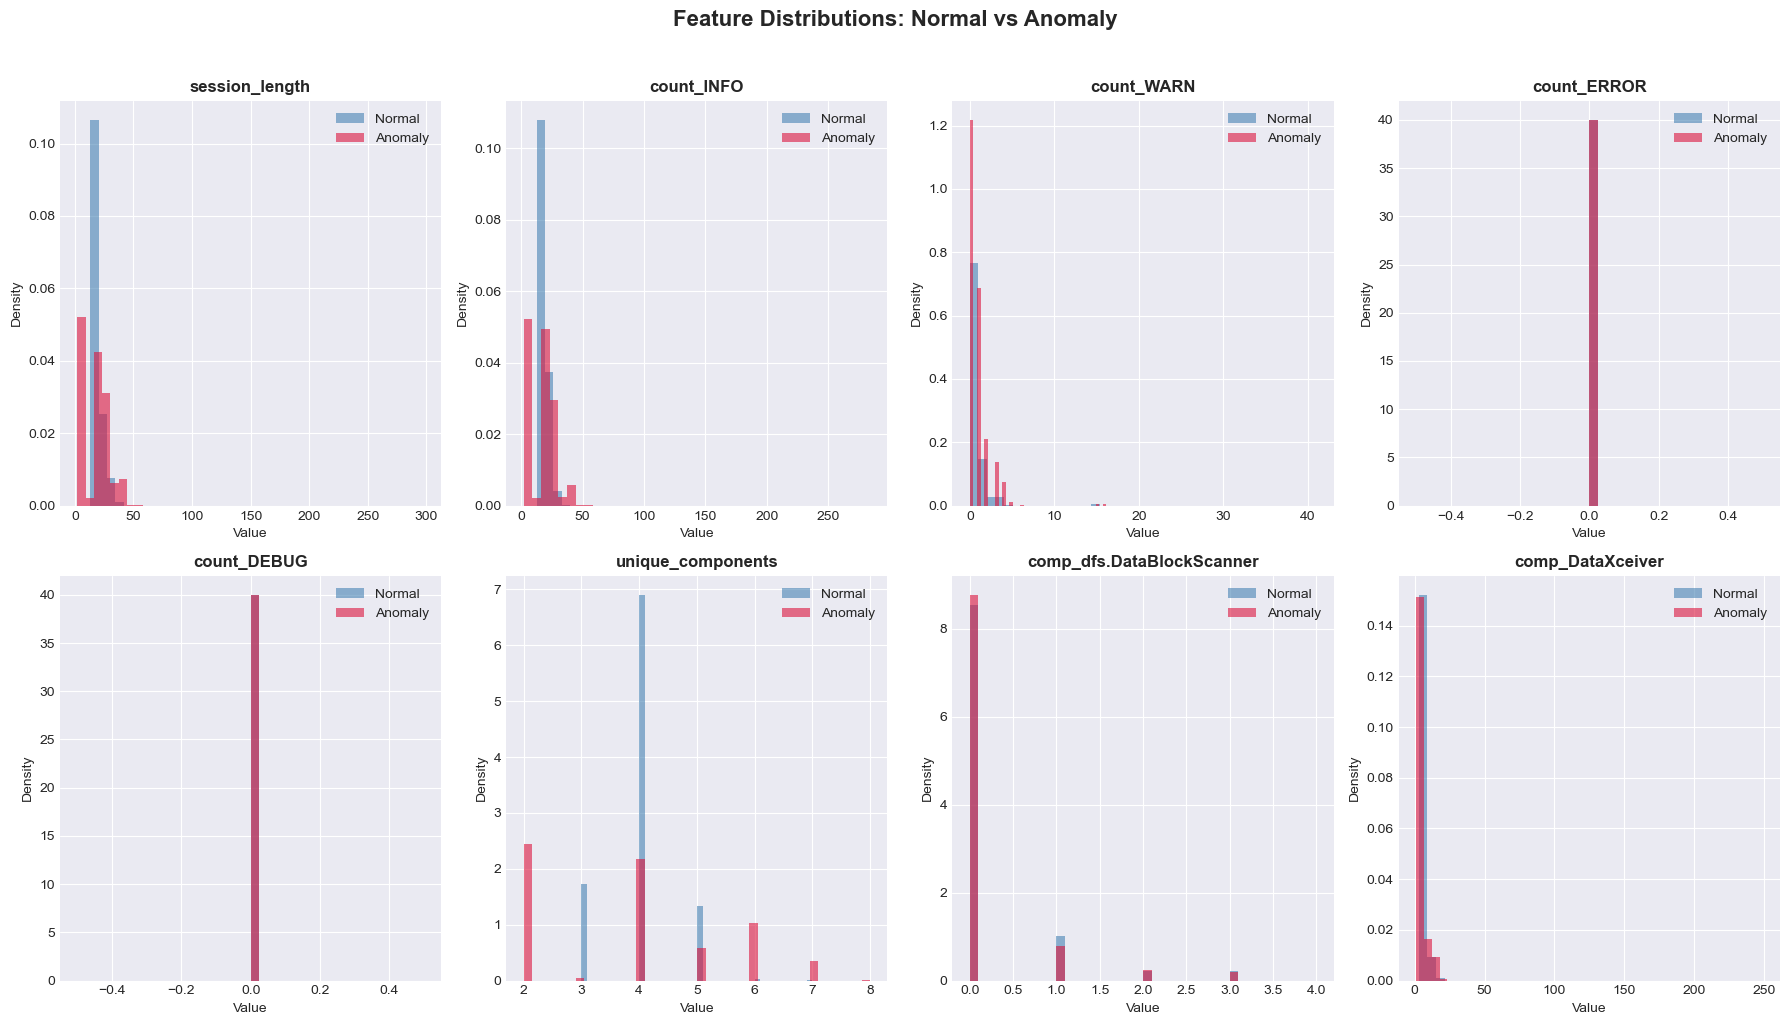

 Plot saved!


In [26]:
# Which features differ most between Normal and Anomaly sessions?
# This tells us which features our ML models will find most useful

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols[:8]):
    normal_vals  = features_df[features_df['Label'] == 'Normal'][col]
    anomaly_vals = features_df[features_df['Label'] == 'Anomaly'][col]
    
    axes[i].hist(normal_vals,  bins=40, alpha=0.6, 
                 label='Normal',  color='steelblue',  density=True)
    axes[i].hist(anomaly_vals, bins=40, alpha=0.6, 
                 label='Anomaly', color='crimson', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Distributions: Normal vs Anomaly', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results/plots/feature_distributions.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved!")

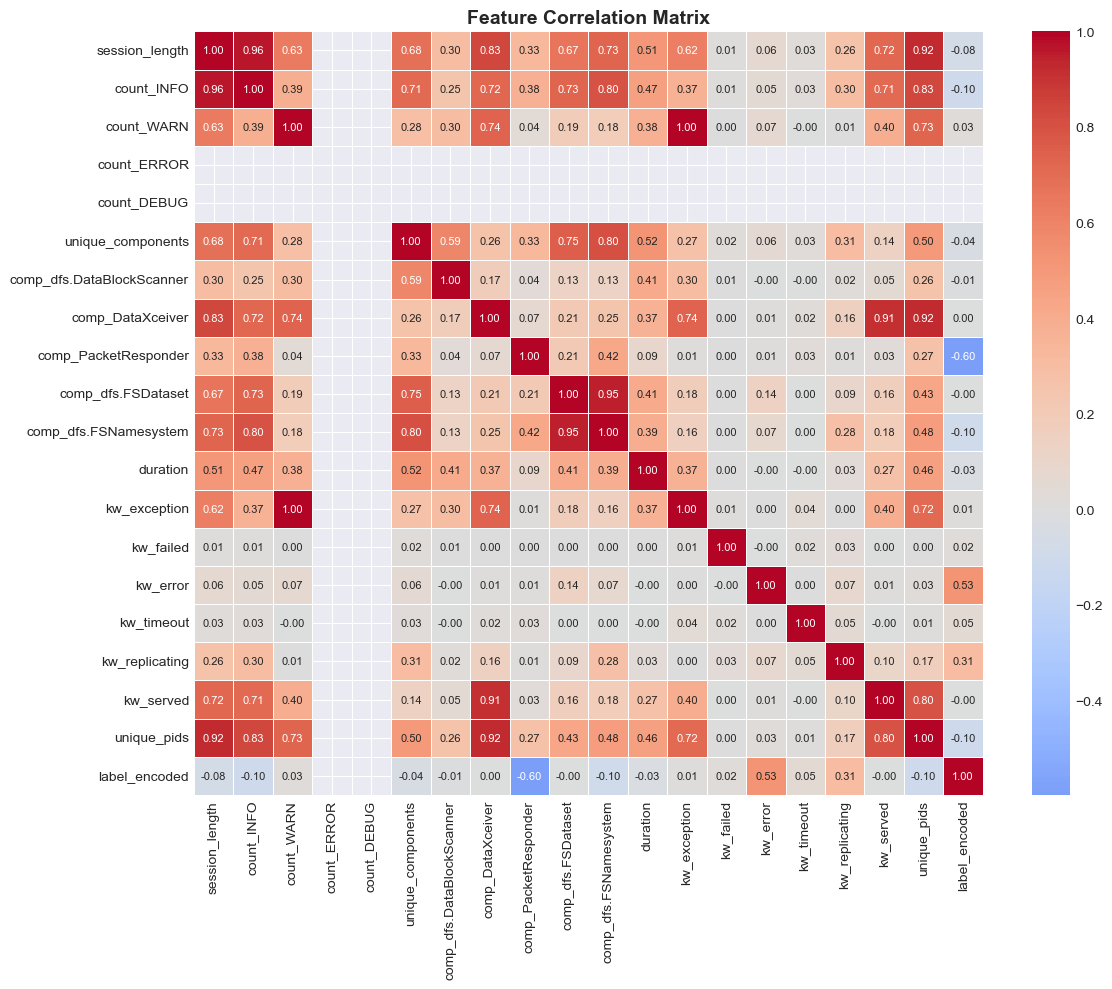

 Heatmap saved!


In [27]:
# Shows how features relate to each other and to the label
# High correlation with label = powerful feature

corr_df = features_df[feature_cols + ['label_encoded']].corr()

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("results/plots/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved!")

In [28]:
import joblib

# Save feature matrix and labels
np.save("data/features/X_scaled.npy", X_scaled)
np.save("data/features/X_raw.npy", X)
np.save("data/features/y.npy", y)

# Save the full features dataframe
features_df.to_csv("data/features/features_df.csv", index=False)

# Save the scaler (needed later for evaluation)
joblib.dump(scaler, "models/scaler.pkl")

# Save feature column names
with open("data/features/feature_cols.txt", "w") as f:
    for col in feature_cols:
        f.write(col + "\n")

print(" Saved:")
print("   data/features/X_scaled.npy")
print("   data/features/X_raw.npy")
print("   data/features/y.npy")
print("   data/features/features_df.csv")
print("   models/scaler.pkl")
print("   data/features/feature_cols.txt")
print()
print("=" * 50)
print("   PHASE 3 COMPLETE!")
print("=" * 50)
print()
print(f"   Sessions engineered : {len(features_df):,}")
print(f"   Features created    : {len(feature_cols)}")
print(f"   Anomaly rate        : {y.mean()*100:.2f}%")
print()
print(" Ready for Phase 4: Model Training!")

 Saved:
   data/features/X_scaled.npy
   data/features/X_raw.npy
   data/features/y.npy
   data/features/features_df.csv
   models/scaler.pkl
   data/features/feature_cols.txt

   PHASE 3 COMPLETE!

   Sessions engineered : 575,061
   Features created    : 19
   Anomaly rate        : 2.93%

 Ready for Phase 4: Model Training!
